# Air Quality India — Data Profiling

**Objective:** Explore `city_hour.csv` (primary source) and `city_day.csv` (reconciliation reference)
before writing any production ETL code. This notebook is exploratory only — all reusable logic
lives in `src/` modules, not here.


In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt

from src import config, extract

pd.set_option('display.max_columns', None)


## 1. Source loading

In [2]:
hour_df = extract.extract_city_hour(config.CITY_HOUR_FILE)
day_df = extract.extract_city_day(config.CITY_DAY_FILE)

print("city_hour.csv:", hour_df.shape)
print("city_day.csv: ", day_df.shape)


city_hour.csv: (707875, 16)
city_day.csv:  (29531, 16)


## 2. Schema

In [3]:
hour_df.dtypes

City              str
Datetime          str
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket        str
dtype: object

In [4]:
hour_df.head()

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01 01:00:00,NaN,NaN,1.00,40.01,36.37,NaN,1.00,122.07,NaN,0.0,0.0,0.0,NaN,NaN
1,Ahmedabad,2015-01-01 02:00:00,NaN,NaN,0.02,27.75,19.73,NaN,0.02,85.90,NaN,0.0,0.0,0.0,NaN,NaN
2,Ahmedabad,2015-01-01 03:00:00,NaN,NaN,0.08,19.32,11.08,NaN,0.08,52.83,NaN,0.0,0.0,0.0,NaN,NaN
3,Ahmedabad,2015-01-01 04:00:00,NaN,NaN,0.30,16.45,9.20,NaN,0.30,39.53,153.58,0.0,0.0,0.0,NaN,NaN
4,Ahmedabad,2015-01-01 05:00:00,NaN,NaN,0.12,14.90,7.85,NaN,0.12,32.63,NaN,0.0,0.0,0.0,NaN,NaN


## 3. Grain

* `city_hour.csv` — grain is **City + Datetime** (hourly readings).
* `city_day.csv` — grain is **City + Date** (daily readings, published independently).

Verify there are no duplicate keys at the expected grain in the raw source.


In [5]:
print("Duplicate City+Datetime in city_hour:", hour_df.duplicated(subset=['City', 'Datetime']).sum())
print("Duplicate City+Date in city_day:      ", day_df.duplicated(subset=['City', 'Date']).sum())


Duplicate City+Datetime in city_hour: 0
Duplicate City+Date in city_day:       0


## 4. Date coverage

In [6]:
hour_dt = pd.to_datetime(hour_df['Datetime'], errors='coerce')
day_dt = pd.to_datetime(day_df['Date'], errors='coerce')

print("city_hour date range:", hour_dt.min(), "to", hour_dt.max())
print("city_day date range: ", day_dt.min(), "to", day_dt.max())


city_hour date range: 2015-01-01 01:00:00 to 2020-07-01 00:00:00
city_day date range:  2015-01-01 00:00:00 to 2020-07-01 00:00:00


## 5. City coverage

In [7]:
print("Cities in city_hour:", hour_df['City'].nunique())
print("Cities in city_day:  ", day_df['City'].nunique())

set(hour_df['City'].unique()) == set(day_df['City'].unique())


Cities in city_hour: 26
Cities in city_day:   26


True

## 6. Missing values

In [8]:
missing_pct = (hour_df.isna().mean() * 100).round(2).sort_values(ascending=False)
missing_pct


Xylene        64.39
PM10          41.92
NH3           38.50
Toluene       31.16
Benzene       23.12
PM2.5         20.50
SO2           18.42
O3            18.25
AQI_Bucket    18.23
AQI           18.23
NOx           17.41
NO2           16.55
NO            16.48
CO            12.22
Datetime       0.00
City           0.00
dtype: float64

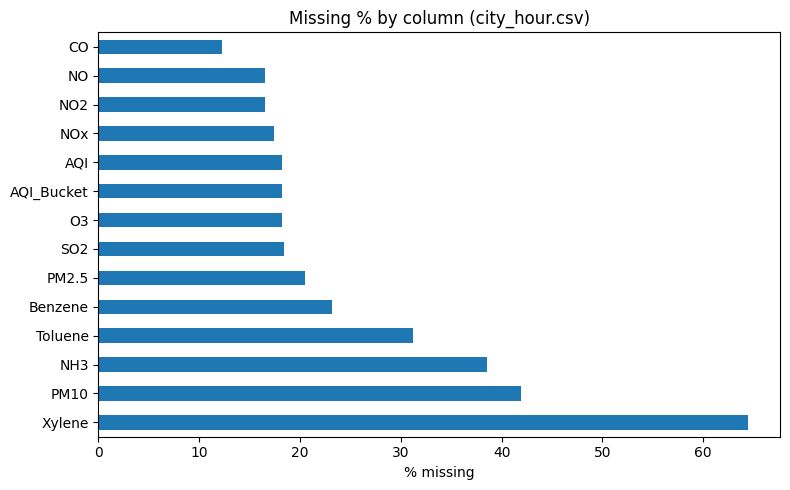

In [9]:
missing_pct.drop(['City', 'Datetime']).plot(kind='barh', figsize=(8, 5), title='Missing % by column (city_hour.csv)')
plt.xlabel('% missing')
plt.tight_layout()
plt.show()


**Finding:** Missing rates range from ~12% (CO) to ~64% (Xylene). This is a real-world air-quality
sensor dataset — sensors go offline, get serviced, or aren't installed for every pollutant at every
station. Per the project's design principle, none of these are imputed; the transform layer instead
tracks `observation_count` / `completeness_pct` per City+Date so downstream analysts can judge how
much to trust a given average.

## 7. Duplicates (re-check, formally)

In [10]:
dupes = hour_df[hour_df.duplicated(subset=['City', 'Datetime'], keep=False)]
print("Duplicate City+Datetime rows:", len(dupes))


Duplicate City+Datetime rows: 0


## 8. Timestamp gaps

A timestamp gap means an hourly *record is entirely missing* from the source — not that a pollutant
value inside an existing record is NULL. We check this per city against each city's own active date
range (since cities joined the monitoring network at different times).

In [11]:
gaps = hour_df.copy()
gaps['Datetime'] = pd.to_datetime(gaps['Datetime'], errors='coerce')
g = gaps.groupby('City')['Datetime'].agg(['min', 'max', 'count'])
g['expected_hours'] = ((g['max'] - g['min']).dt.total_seconds() / 3600 + 1).astype(int)
g['missing_hours'] = g['expected_hours'] - g['count']
g['gap_pct'] = (g['missing_hours'] / g['expected_hours'] * 100).round(3)
g.sort_values('gap_pct', ascending=False)


,min,max,count,expected_hours,missing_hours,gap_pct
City,,,,,,
Ahmedabad,2015-01-01 01:00:00,2020-07-01,48192,48192,0,0.0
Aizawl,2020-03-11 09:00:00,2020-07-01,2680,2680,0,0.0
Amaravati,2017-11-24 17:00:00,2020-07-01,22784,22784,0,0.0
Amritsar,2017-02-27 12:00:00,2020-07-01,29269,29269,0,0.0
Bengaluru,2015-01-01 01:00:00,2020-07-01,48192,48192,0,0.0
Bhopal,2019-09-17 10:00:00,2020-07-01,6903,6903,0,0.0
Brajrajnagar,2017-12-07 21:00:00,2020-07-01,22468,22468,0,0.0
Chandigarh,2019-09-02 10:00:00,2020-07-01,7263,7263,0,0.0
Chennai,2015-01-01 01:00:00,2020-07-01,48192,48192,0,0.0


**Finding:** Gaps within each city's own active window are effectively 0% — once a monitoring station comes online, it reports every hour with very few exceptions. Most "missingness" in this dataset is at the *measurement* level (NULL pollutant values), not the *record* level.

## 9. Numeric ranges & extreme values

In [12]:
pollutants = config.POLLUTANT_COLUMNS
hour_df[pollutants + ['AQI']].describe().T


,count,mean,std,min,25%,50%,75%,max
PM2.5,562787.0,67.622994,74.730496,0.01,26.20,46.42,79.49,999.99
PM10,411138.0,119.075804,104.224752,0.01,52.38,91.50,147.52,1000.00
NO,591243.0,17.421755,32.095211,0.01,3.84,7.96,16.15,499.99
NO2,590753.0,28.885157,29.162194,0.01,10.81,20.32,36.35,499.51
NOx,584651.0,32.287565,39.756669,0.00,10.66,20.79,37.15,498.61
NH3,435333.0,23.607959,28.831900,0.01,8.12,15.38,29.23,499.97
CO,621358.0,2.183539,10.970514,0.00,0.42,0.80,1.37,498.57
SO2,577502.0,14.038307,19.305540,0.01,4.88,8.37,14.78,199.96
O3,578667.0,34.798979,29.806379,0.01,13.42,26.24,47.62,497.62
Benzene,544229.0,3.087595,16.456599,0.00,0.05,0.86,2.75,498.07


In [13]:
hour_df[pollutants].quantile([0.5, 0.95, 0.99, 0.999, 1.0]).T


,0.500,0.950,0.990,0.999,1.000
PM2.5,46.42,201.08,356.4256,840.11770,999.99
PM10,91.50,326.64,521.5726,842.80437,1000.00
NO,7.96,69.12,165.1558,341.12274,499.99
NO2,20.32,81.94,143.1296,263.77720,499.51
NOx,20.79,105.59,204.1100,365.43100,498.61
NH3,15.38,65.63,142.8536,340.76088,499.97
CO,0.80,6.18,28.2800,172.88215,498.57
SO2,8.37,45.62,109.3100,180.07998,199.96
O3,26.24,94.65,137.5800,187.58334,497.62
Benzene,0.86,9.49,28.7700,384.75092,498.07


**Finding:** No negative values were found in this dataset. Some pollutant readings and AQI values
are far above typical ranges (e.g. AQI up to ~3133, official scale tops out at 500). These are flagged
by the validation layer via `SUSPICIOUS_VALUE_THRESHOLDS` in `src/config.py` rather than deleted —
extreme pollution events are real and analytically interesting, and a hard delete would silently
destroy signal without evidence the reading is wrong.

## 10. Engineering decisions carried into `src/`

1. **Primary source:** `city_hour.csv` drives the pipeline. `city_day.csv` is used only for
   reconciliation after we build our own daily aggregate — never loaded as an independent fact.
2. **Row-drop policy:** only structurally broken rows (null City, unparseable Datetime, exact
   duplicate key) are excluded before load. Extreme values are flagged, never deleted. Missing
   measurements are never imputed.
3. **Daily aggregation:** average of *available* hourly readings per City+Date, with
   `observation_count` (records present) and `completeness_pct` (`observation_count / 24`) carried
   alongside so consumers can gauge reliability.
4. **AQI bucket on the daily fact:** `source_aqi` is the mean of hourly AQI values (not a new
   sub-index calculation), mapped to a CPCB bucket label for convenience — clearly distinct from
   `city_day.csv`'s own official `AQI_Bucket`, against which it is reconciled.
